In [1]:
!pip install plotly

In [2]:
!pip install anndata==0.8.0

In [3]:
!pip install -U kaleido

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE

In [2]:
sam_mg = SAM()
sam_mg.load_data('../../Subclustering/MNPO/SAM_Allen_Institute_MNPO.h5ad')

In [3]:
sam_mo = SAM()
sam_mo.load_data('../../Subclustering/MNPO/SAM_MO_soupx_plus5_cleaned_MNPO_07282026.h5ad')

In [4]:
sam_cj = SAM()
sam_cj.load_data('../../Subclustering/MNPO/SAM_CJ_joined_v2_cleaned_09022026_MNPO.h5ad')

In [5]:
sam_ac = SAM()
sam_ac.load_data('../../Subclustering/MNPO/SAM_AC_ncbi_soupx_cleaned_09022026_MNPO.h5ad')

In [6]:
sam_ri = SAM()
sam_ri.load_data('../../Subclustering/MNPO/SAM_RI_joined_cleaned_08032026_sssubclass_MNPO.h5ad')

In [7]:
sm = load_samap('../../Subclustering/MNPO/sm_hypoorgs_MNPO_09022026.pkl')

In [18]:
sm.sams['ri'].adata.X

<432x23867 sparse matrix of type '<class 'numpy.float32'>'
	with 519679 stored elements in Compressed Sparse Row format>

In [19]:
sam_ri.adata.X

<432x23867 sparse matrix of type '<class 'numpy.float32'>'
	with 519679 stored elements in Compressed Sparse Row format>

In [20]:
sm.sams['mg'].adata.obs.columns

Index(['Unnamed: 0', 'cell_label', 'cell_barcode',
       'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label',
       'entity', 'brain_section_label', 'library_method',
       'region_of_interest_acronym', 'donor_label', 'donor_genotype',
       'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias',
       'subclass_id_label', 'supertype_id_label', 'class_id_label',
       'eq_supertype', 'eq_supertype_cl', 'eq_supertype_cl_v2',
       'leiden_clusters'],
      dtype='object')

In [21]:
sm.sams['mg'].adata.obs['eq_supertype_cl_v5'] = sm.sams['mg'].adata.obs['eq_supertype_cl_v2']

In [22]:
orgs = ['mg','mo','cj','ac','ri']
pairs = [list(pair) for pair in itertools.combinations(orgs, 2)]
level = 'eq_supertype_cl_v5'
for org_one, org_two in pairs:
    print(org_one, org_two)
    df_plt = pd.DataFrame(columns = ['celltype_org','celltype_ref','mapping','num_cells'])
    a = 0
    keys = {org_one:level,org_two:level}
    D,MappingTable = get_mapping_scores(sm,keys)

    lim_MappingTable = MappingTable.filter(like=org_one + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]
    lim_MappingTable.to_csv('../../Subclustering/MNPO/Hypo/' + org_one + '_' + org_two + '_mapping_v4_09022026_clusters.csv')

mg mo


/scratch/miniconda/lib/python3.7/site-packages/samap/analysis.py:1609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  samap.adata.obs[l] = pd.Categorical(cl)


mg cj
mg ac
mg ri
mo cj
mo ac
mo ri
cj ac
cj ri
ac ri


In [27]:
#all dfs load
ct = 'MNPO'
organisms = ['mg', 'mo','cj','ac','ri']
level = 'eq_supertype_cl_v5'

# Generate all unique pairs and read CSVs once
mapping = {}
for i, org1 in enumerate(organisms):
    for j, org2 in enumerate(organisms):
        key = f"{org1}_{org2}".upper()
        if i == j:
            uct = sm.sams[org1].adata.obs[level].unique()
            mapping[key] = pd.DataFrame(data = np.eye(len(uct)),index = [org1 + '_' + i for i in uct], columns = [org1 + '_' + i for i in uct])
        if i < j:
            # Read the file for this pair
            df = pd.read_csv(f'../../Subclustering/{ct}/Hypo/{org1}_{org2}_mapping_v4_09022026_clusters.csv', 
                             index_col='Unnamed: 0')
            mapping[key] = df
        else:
            # Derive from the transpose of the already-read file
            key = f"{org1}_{org2}".upper()
            reverse_key = f"{org2}_{org1}".upper()
            mapping[key] = mapping[reverse_key].T

In [28]:
organism_rows = {}
for org1 in organisms:
    dfs = [mapping[f"{org1}_{org2}".upper()] for org2 in organisms]
    organism_rows[org1.upper()] = pd.concat(dfs)

In [29]:
pvh_mapping = pd.concat([organism_rows[i.upper()] for i in organisms], axis = 1)

<AxesSubplot:>

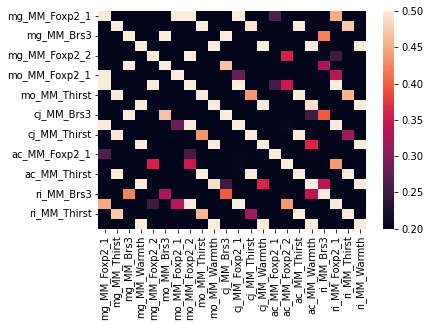

In [30]:
sns.heatmap(pvh_mapping, vmin = .2, vmax = .5)

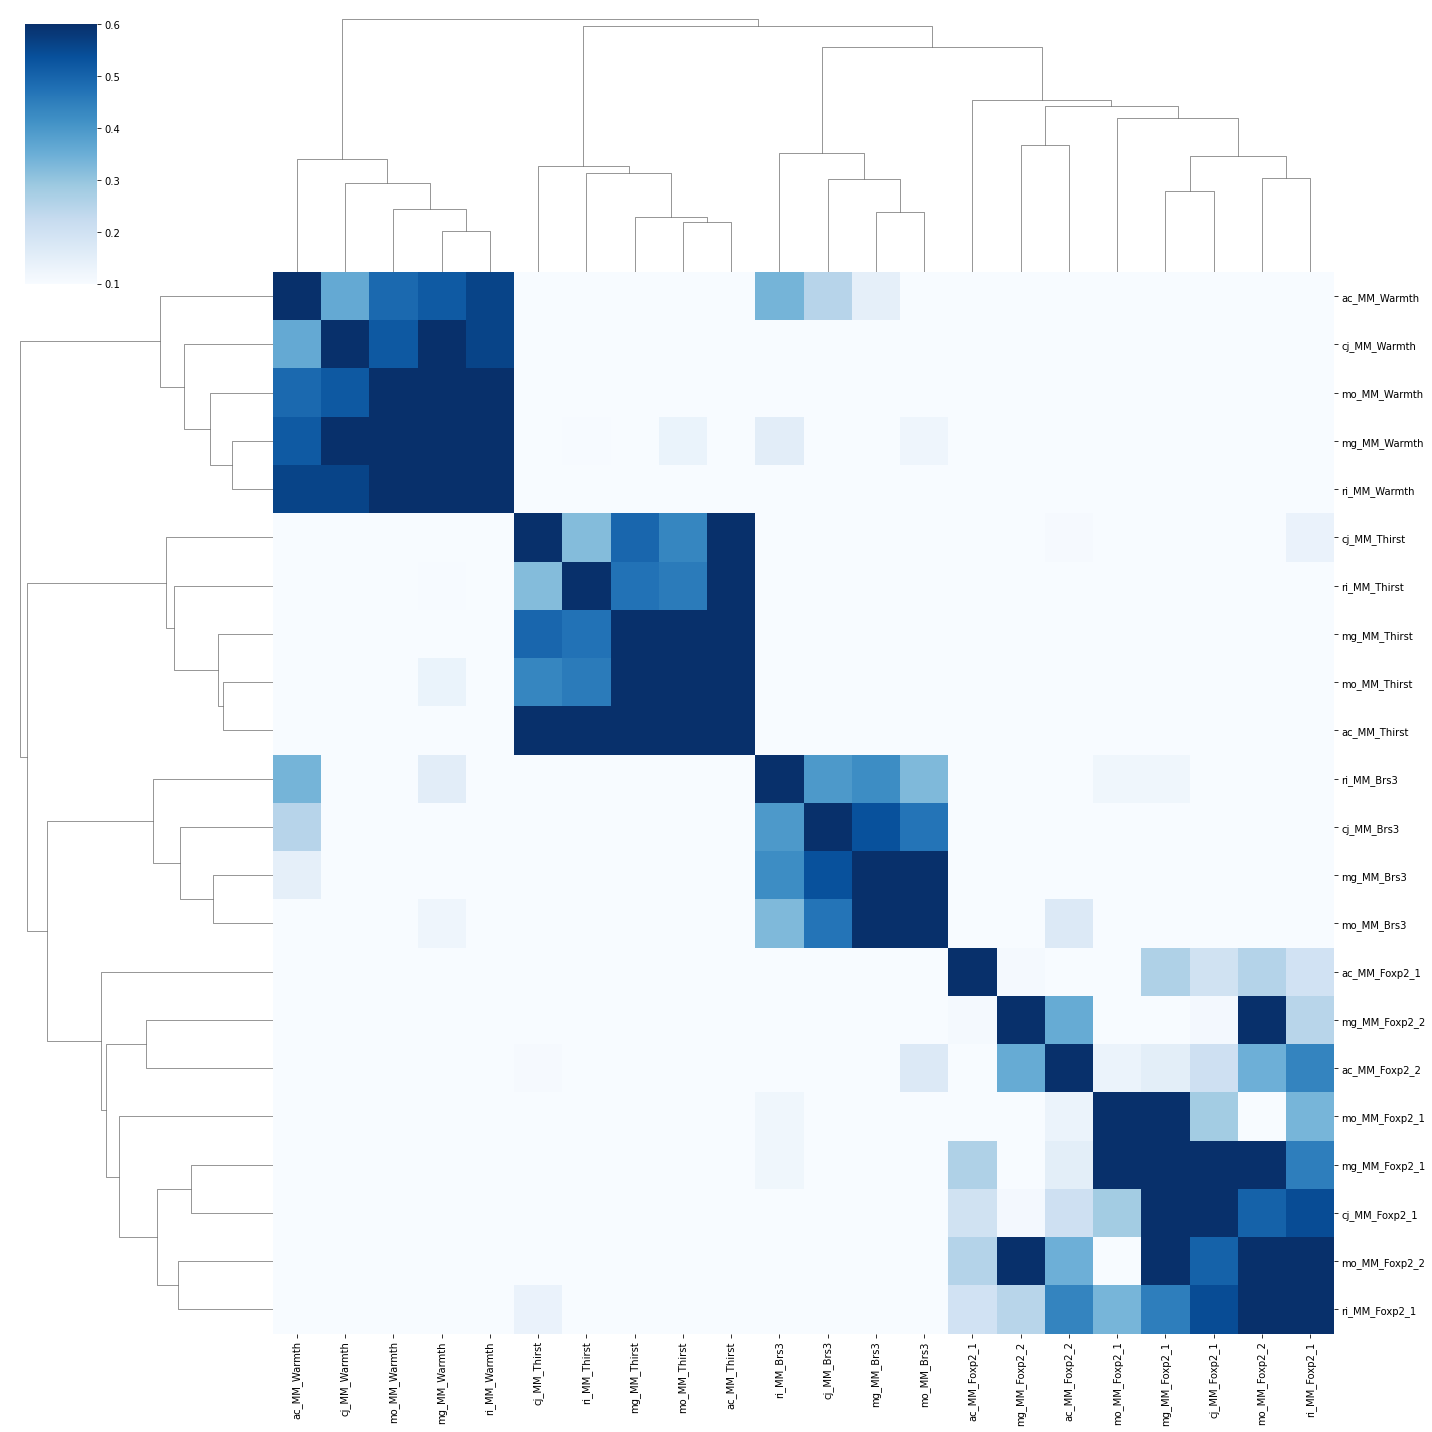

In [33]:
g =sns.clustermap(pvh_mapping, vmax = .6, vmin = .1,cmap = 'Blues',figsize=(20,20))
#plt.savefig('MNPO_mapping_hypothalamus_04102026.svg')

In [34]:
reorder_row = g.dendrogram_row.reordered_ind
reorder_col = g.dendrogram_col.reordered_ind

In [35]:
pvh_mapping.index[reorder_row]

Index(['ac_MM_Warmth', 'cj_MM_Warmth', 'mo_MM_Warmth', 'mg_MM_Warmth',
       'ri_MM_Warmth', 'cj_MM_Thirst', 'ri_MM_Thirst', 'mg_MM_Thirst',
       'mo_MM_Thirst', 'ac_MM_Thirst', 'ri_MM_Brs3', 'cj_MM_Brs3',
       'mg_MM_Brs3', 'mo_MM_Brs3', 'ac_MM_Foxp2_1', 'mg_MM_Foxp2_2',
       'ac_MM_Foxp2_2', 'mo_MM_Foxp2_1', 'mg_MM_Foxp2_1', 'cj_MM_Foxp2_1',
       'mo_MM_Foxp2_2', 'ri_MM_Foxp2_1'],
      dtype='object')

In [36]:
reorder = ['mg_MM_Thirst','mo_MM_Thirst','cj_MM_Thirst','ac_MM_Thirst','ri_MM_Thirst',
          'mg_MM_Warmth', 'mo_MM_Warmth','cj_MM_Warmth','ac_MM_Warmth', 'ri_MM_Warmth',
          'mg_MM_Foxp2_1','mo_MM_Foxp2_1','cj_MM_Foxp2_1','ac_MM_Foxp2_1','ri_MM_Foxp2_1','mg_MM_Foxp2_2','mo_MM_Foxp2_2','ac_MM_Foxp2_2',
          'mg_MM_Brs3','mo_MM_Brs3','cj_MM_Brs3','ri_MM_Brs3']

In [37]:
for item in pvh_mapping.index:
    if item not in reorder:
        print(item)

In [38]:
pvh_mapping_ord = pvh_mapping.loc[reorder,:]
pvh_mapping_ord = pvh_mapping_ord.loc[:,reorder]

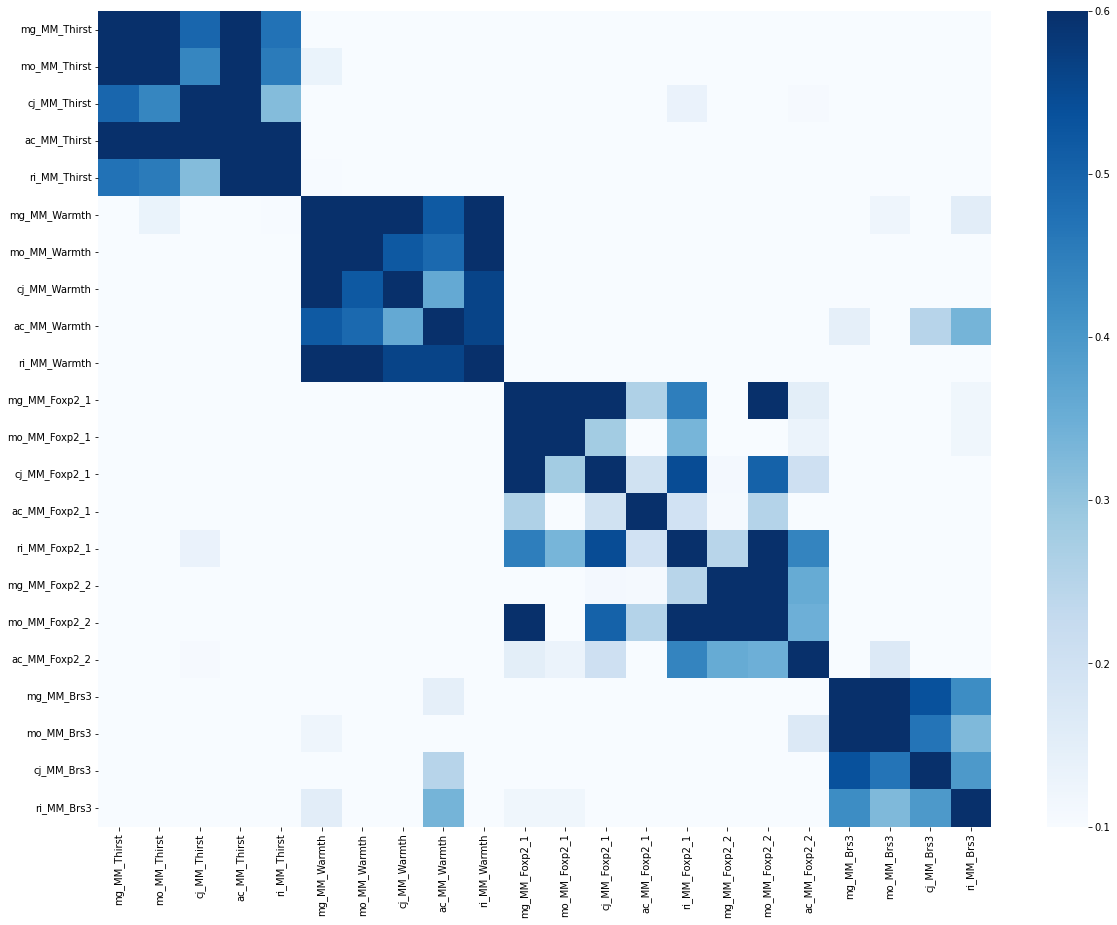

In [39]:
plt.figure(figsize = (20,15))
sns.heatmap(pvh_mapping_ord, vmax = .6, vmin = .1,cmap = 'Blues')
plt.savefig('../../Figures/Figures_09022026/MNPO_boxplot_hypothalamusri_09022026.svg',bbox_inches='tight')
plt.savefig('../../Figures/Figures_09022026/MNPO_boxplot_hypothalamusri_09022026.pdf',bbox_inches='tight')